<a href="https://colab.research.google.com/github/AminKJun/AminKJun/blob/main/Predictive_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Loading the necessary libraries for the project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
#Uploading the dataset
dataset=pd.read_csv('/content/loan_approval_dataset.csv')

In [ ]:
#Viewing the dataset
dataset.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
dataset.nunique() #Returns the number of unique elements in each column of the DataFrame

loan_id                      4269
 no_of_dependents               6
 education                      2
 self_employed                  2
 income_annum                  98
 loan_amount                  378
 loan_term                     10
 cibil_score                  601
 residential_assets_value     278
 commercial_assets_value      188
 luxury_assets_value          379
 bank_asset_value             146
 loan_status                    2
dtype: int64

In [ ]:
#Identifying the type of the dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
#Summary of the dataset
dataset.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
#Identifying any Null Values
dataset.isnull().sum()


loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [ ]:
#Identifying Duplicate values
dataset.duplicated().sum()

0

In [ ]:
# Display the original column names
print("Original Column Names:")
print(dataset.columns)

# Remove spaces from column names
dataset.columns = dataset.columns.str.replace(' ', '')

# Display the updated column names without
print("\nUpdated Column Names:")
print(dataset.columns)

Original Column Names:
Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

Updated Column Names:
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


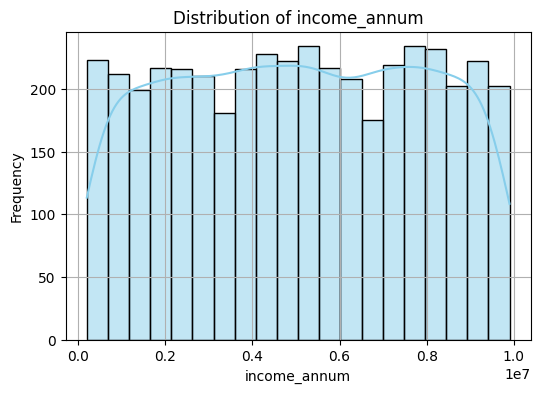

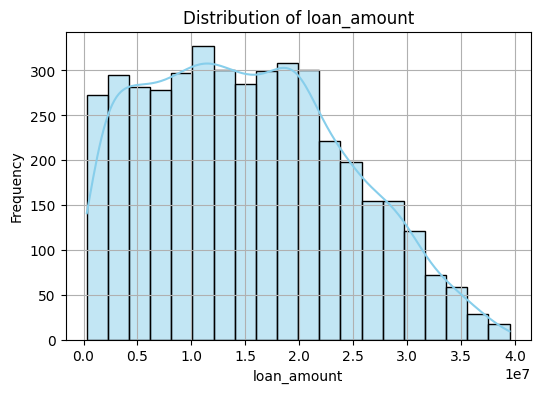

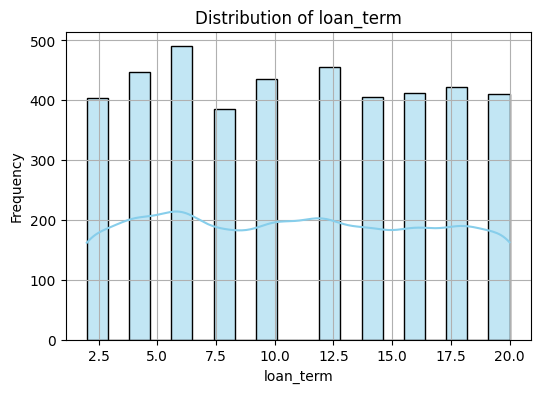

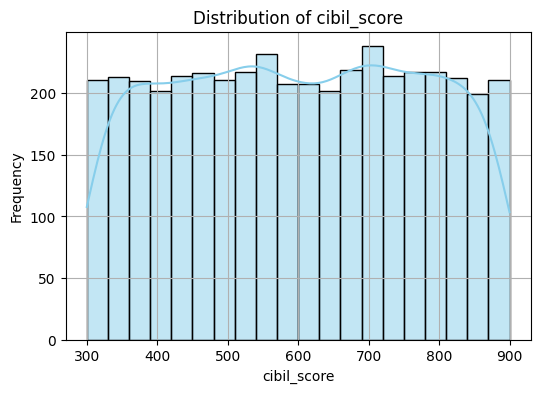

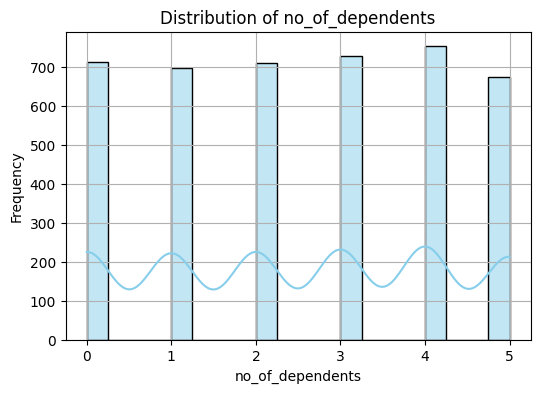

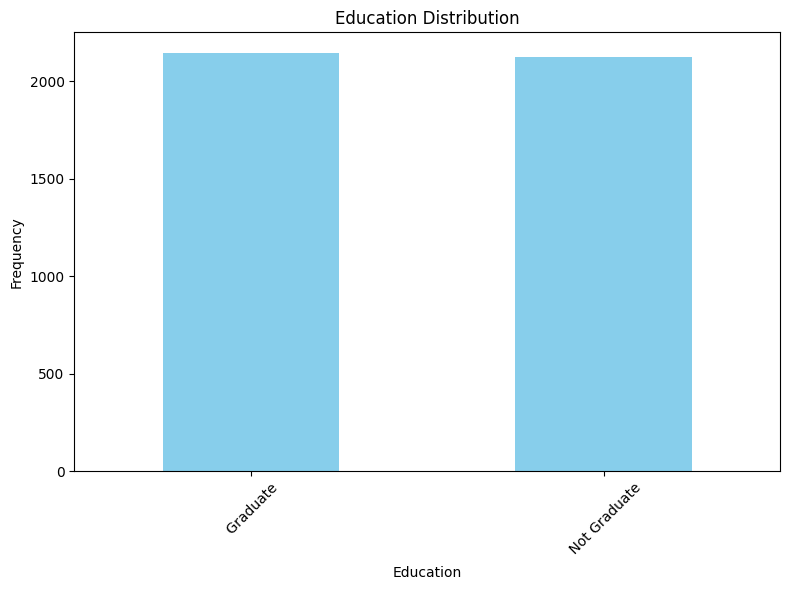

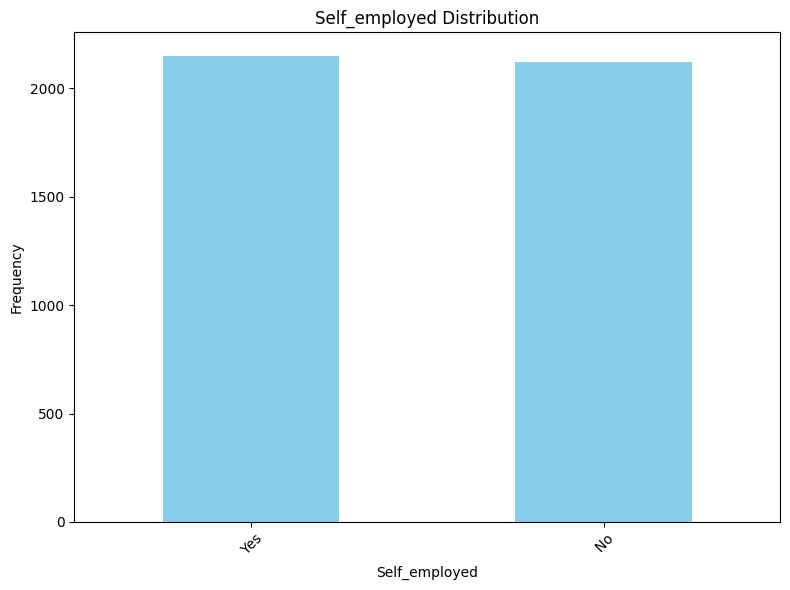

In [ ]:
#EDA
#Univariate
dataset_variables = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'no_of_dependents']
# Checking for normal distribution of numerical independent variables like income_annum, loan_amount and cibil_score
for column in dataset_variables:
    plt.figure(figsize=(6, 4))
    sns.histplot(dataset[column], bins=20, color='skyblue', edgecolor='black', kde=True)
    plt.title('Distribution of ' + column)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(True)  # Add grid for better readability
    plt.show()


# List of categorical features to analyze
categorical_features = ['education', 'self_employed']

# Plot frequency counts and distributions for each categorical feature
for feature in categorical_features:
    plt.figure(figsize=(8, 6))
    dataset[feature].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'{feature.capitalize()} Distribution')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


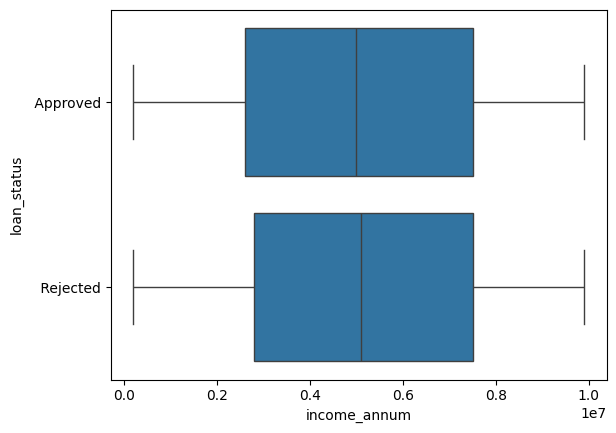

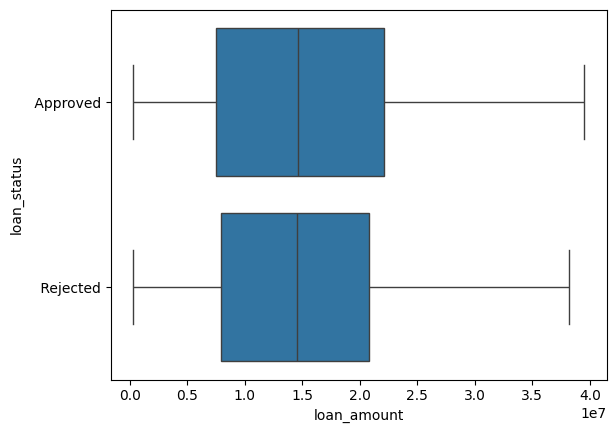

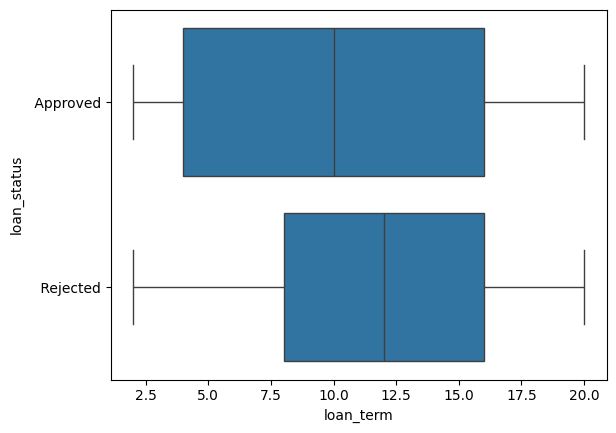

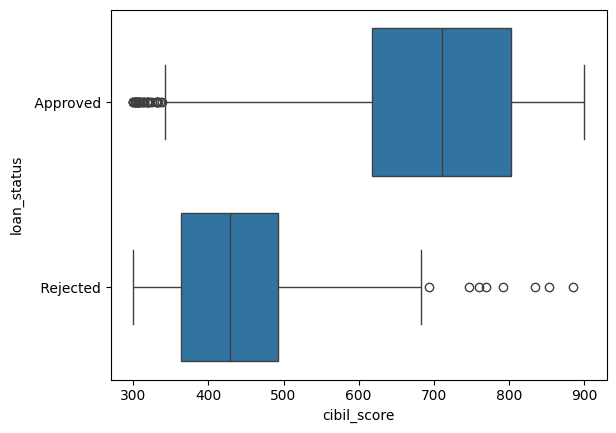

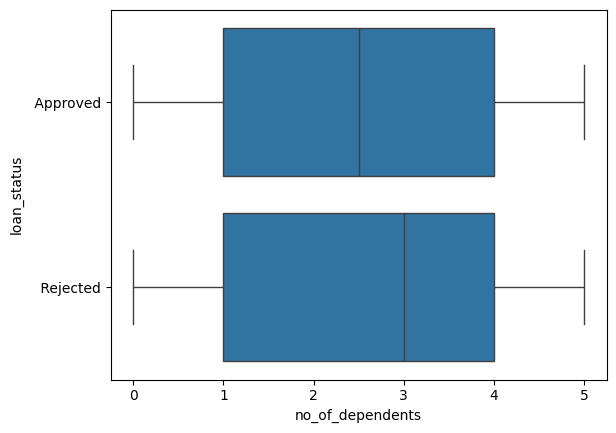

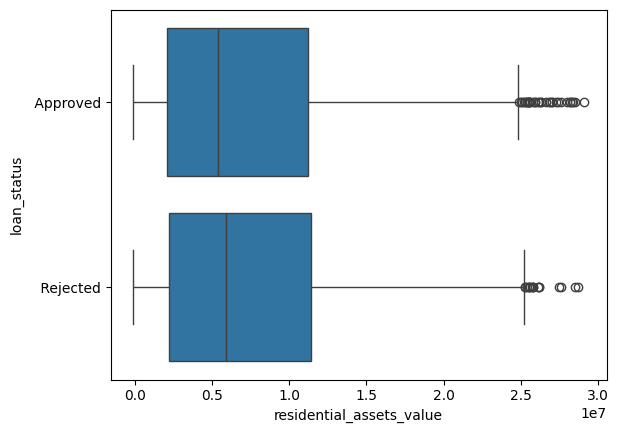

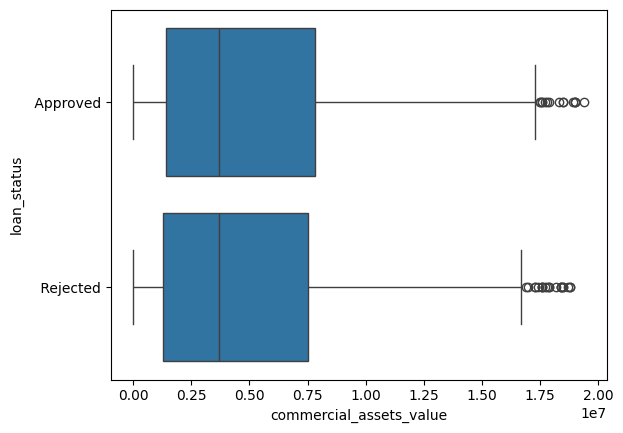

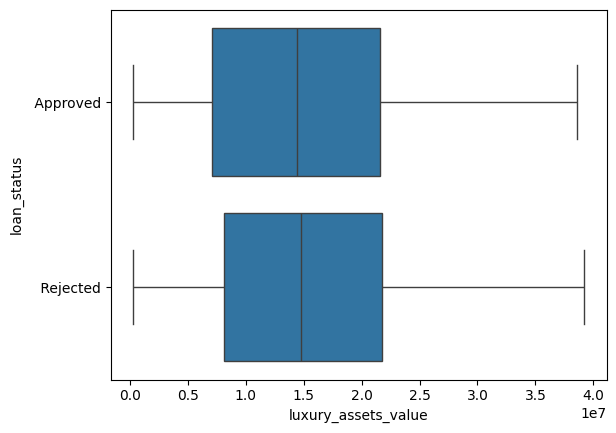

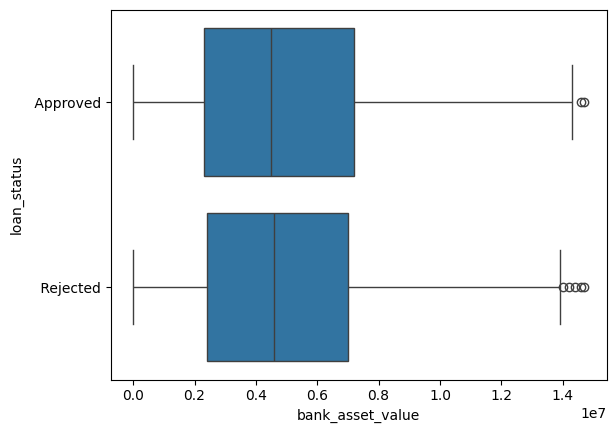

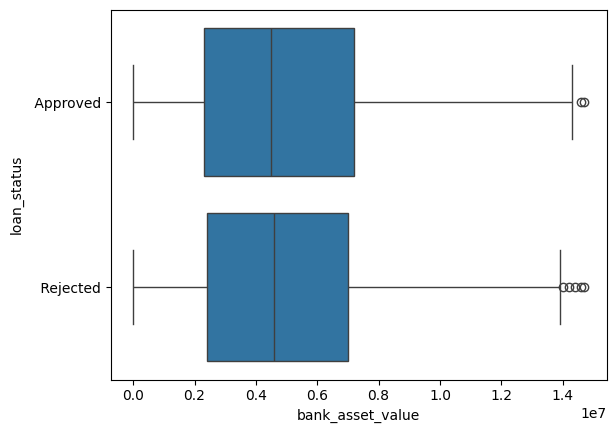

In [ ]:
#Biverate Analysis
sns.boxplot(data=dataset, x="income_annum", y="loan_status")
plt.show()
sns.boxplot(data=dataset, x="loan_amount", y="loan_status")
plt.show()
sns.boxplot(data=dataset, x="loan_term", y="loan_status")
plt.show()
sns.boxplot(data=dataset, x="cibil_score", y="loan_status")
plt.show()
sns.boxplot(data=dataset, x="no_of_dependents", y="loan_status")
plt.show()
sns.boxplot(data=dataset, x="residential_assets_value", y="loan_status")
plt.show()
sns.boxplot(data=dataset, x="commercial_assets_value", y="loan_status")
plt.show()
sns.boxplot(data=dataset, x="luxury_assets_value", y="loan_status")
plt.show()
sns.boxplot(data=dataset, x="bank_asset_value", y="loan_status")
plt.show()
sns.boxplot(data=dataset, x="bank_asset_value", y="loan_status")
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


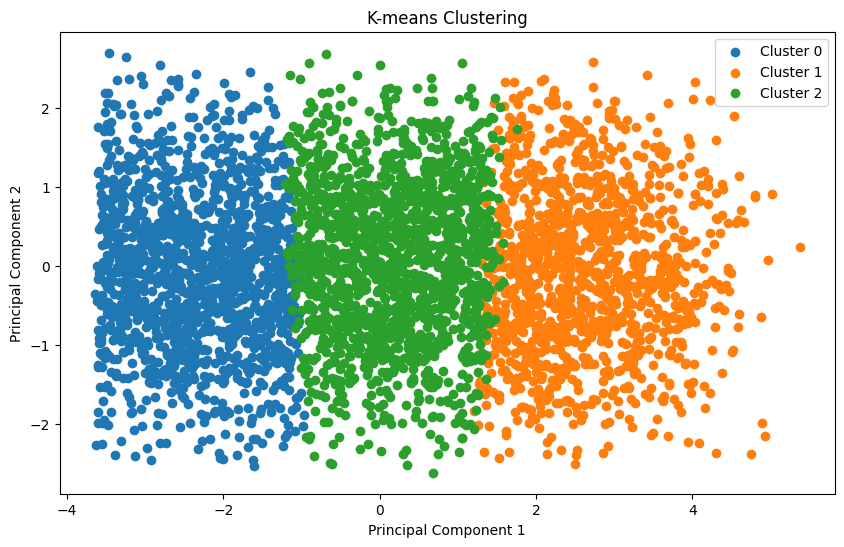

In [ ]:

# Select relevant columns for clustering analysis
# Assuming loan_id is not needed for clustering analysis
selected_data = dataset[['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']]

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(selected_data)

# Perform k-means clustering
k = 3  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(scaled_data)
cluster_labels = kmeans.labels_

# Add cluster labels to the original data
dataset['cluster'] = cluster_labels

# Visualize the clusters (using first two principal components)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
dataset['PC1'] = pca_result[:,0]
dataset['PC2'] = pca_result[:,1]

plt.figure(figsize=(10, 6))
for cluster in range(k):
    plt.scatter(dataset[dataset['cluster'] == cluster]['PC1'],
                dataset[dataset['cluster'] == cluster]['PC2'],
                label='Cluster {}'.format(cluster))
plt.title('K-means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()